In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Superstore.csv', encoding ='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
# Drived ship days

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Ship Days']

0       3
1       3
2       4
3       7
4       7
       ..
9989    2
9990    5
9991    5
9992    5
9993    5
Name: Ship Days, Length: 9994, dtype: int64

In [9]:
df[df.duplicated()]
df.groupby('Order ID').size().sort_values(ascending=False)

Order ID
CA-2017-100111    14
CA-2017-157987    12
US-2016-108504    11
CA-2016-165330    11
CA-2016-105732    10
                  ..
CA-2015-139738     1
CA-2017-113572     1
CA-2015-139374     1
CA-2015-139290     1
CA-2014-100006     1
Length: 5009, dtype: int64

In [10]:
order_df = df.groupby('Order ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()
order_df

,Order ID,Sales,Profit,Quantity
0,CA-2014-100006,377.970,109.6113,3
1,CA-2014-100090,699.192,-19.0890,9
2,CA-2014-100293,91.056,31.8696,6
3,CA-2014-100328,3.928,1.3257,1
4,CA-2014-100363,21.376,7.7192,5
...,...,...,...,...
5004,US-2017-168802,18.368,5.9696,4
5005,US-2017-169320,171.430,16.6721,7
5006,US-2017-169488,56.860,26.5552,7
5007,US-2017-169502,113.410,32.4527,8


# Identify top 5 categories, sub-categories, and regions by sales

In [11]:
df.groupby('Category')['Sales'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(5)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [12]:
df.groupby('Sub-Category')['Sales'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(5)

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

In [13]:
df.groupby('Region')['Sales'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(5)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

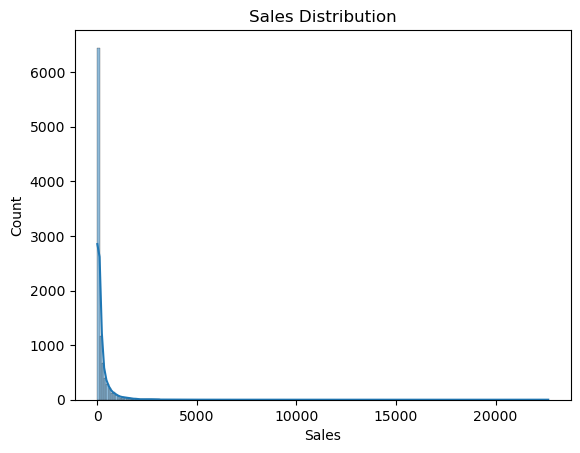

In [15]:
sns.histplot(df['Sales'], kde=True)
plt.title('Sales Distribution')
plt.show()

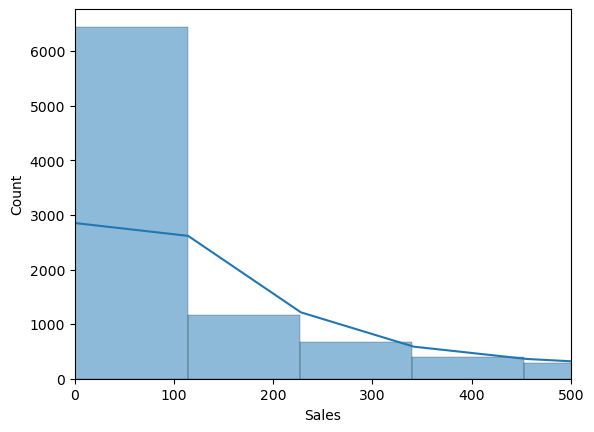

In [16]:
sns.histplot(df['Sales'], kde=True)
plt.xlim(0, 500)  # focus on common range
plt.show()

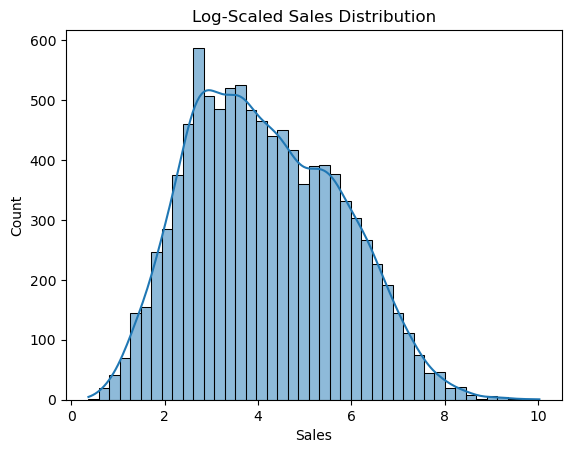

In [17]:
import numpy as np
sns.histplot(np.log1p(df['Sales']), kde=True)
plt.title('Log-Scaled Sales Distribution')
plt.show()

# Profit Distribution

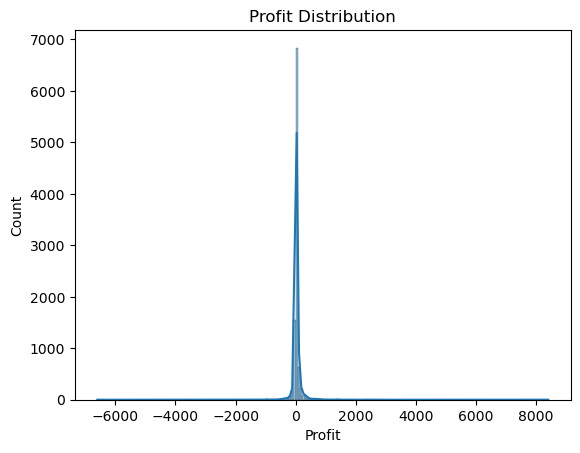

In [18]:
sns.histplot(df['Profit'], kde=True)
plt.title('Profit Distribution')
plt.show()

# Very important business finding:
    
# Many transactions give low profit
# Some transactions cause huge losses (negative profit)
# Indicates:
# High discounts
# Poor pricing strategy

# Discount vs Profit (with Category + Regression Line)

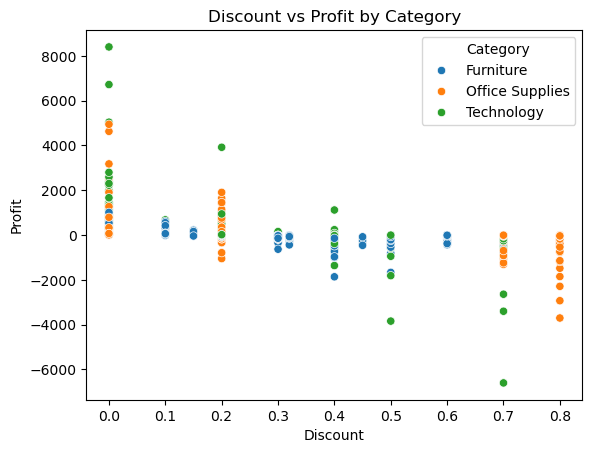

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category'
)

plt.title('Discount vs Profit by Category')
plt.show()

# Add Regression line

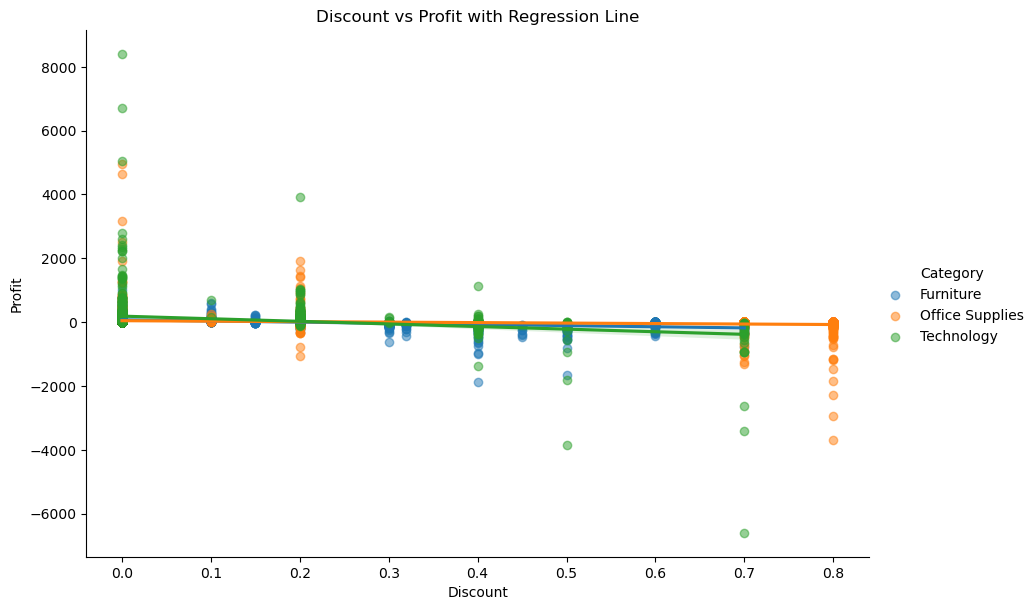

In [20]:
sns.lmplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha':0.5}
)

plt.title('Discount vs Profit with Regression Line')
plt.show()

# High discounts → often negative profit
# Some categories suffer more losses than others
# Clear inverse relationship

In [21]:
# correlation value
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


# Monthly sales trend from 2014–2017 — line chart with Seaborn, spot seasonality

In [22]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

In [23]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

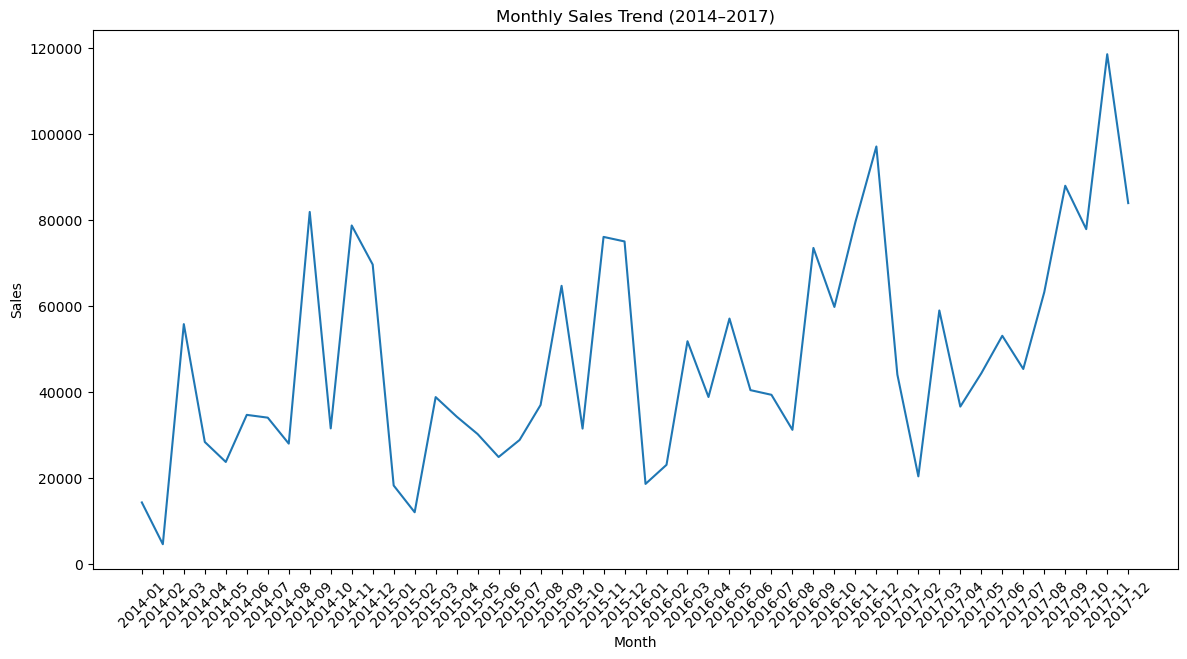

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales'
)

plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (2014–2017)')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

# Heatmap of correlation matrix across numeric columns (Sales, Profit, Discount, Quantity, Ship Days)

In [25]:
cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Ship Days']
corr = df[cols].corr()

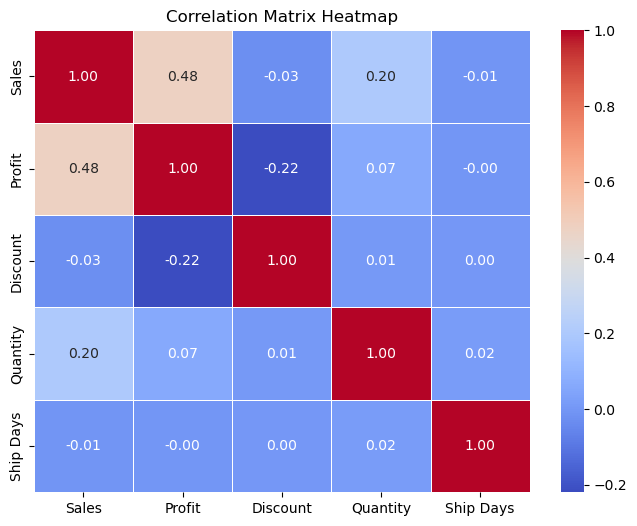

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,      # show values
    fmt=".2f",       # 2 decimal places
    cmap='coolwarm', # color scale
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap')
plt.show()

# Box plots: Profit by Region and by Category — identify outliers

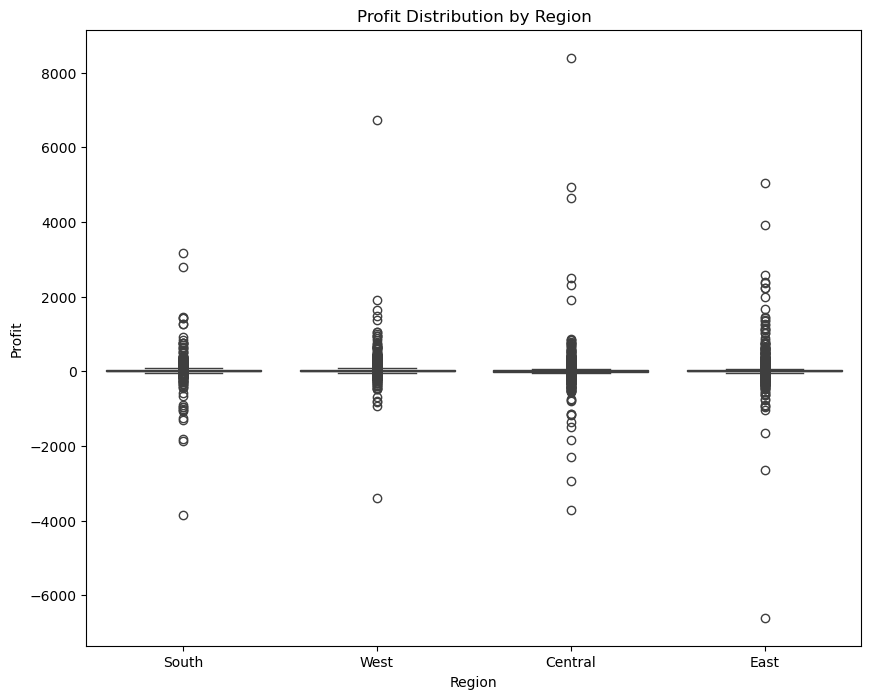

In [27]:
# profit by region

plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x='Region',
    y='Profit'
)

plt.title('Profit Distribution by Region')
plt.show()

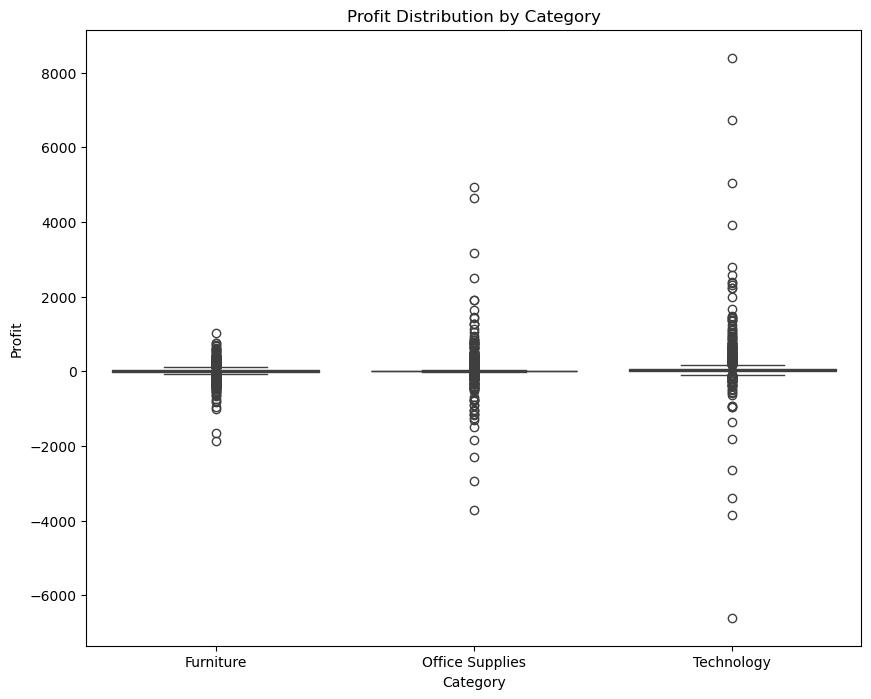

In [28]:
# profit by Category
plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x='Category',
    y='Profit'
)

plt.title('Profit Distribution by Category')
plt.show()

# Bar chart: Top 10 products by revenue vs Top 10 by profit margin

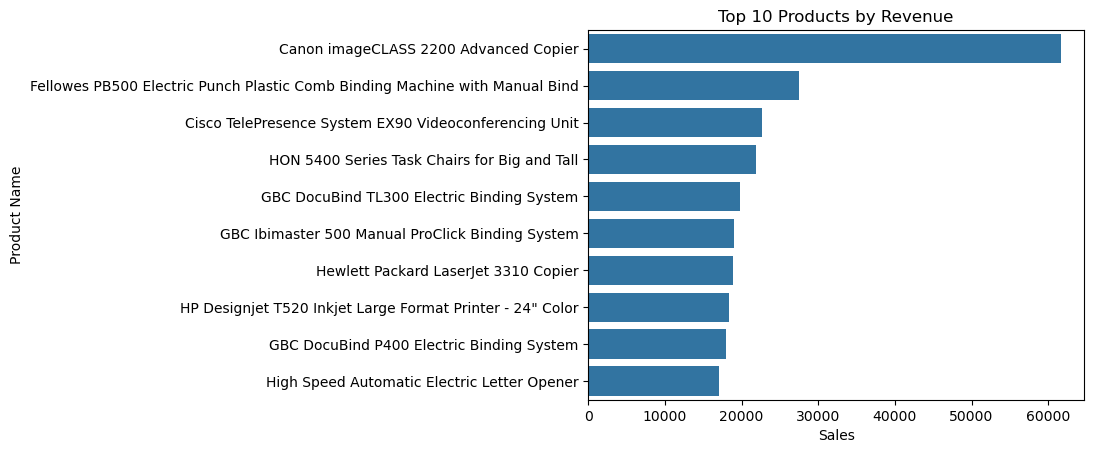

In [29]:
# top 10 products by revenue
top_revenue = df.groupby('Product Name')['Sales'] \
    .sum() \
    .nlargest(10) \
    .reset_index()

sns.barplot(
    data=top_revenue,
    x='Sales',
    y='Product Name'
)

plt.title('Top 10 Products by Revenue')
plt.show()

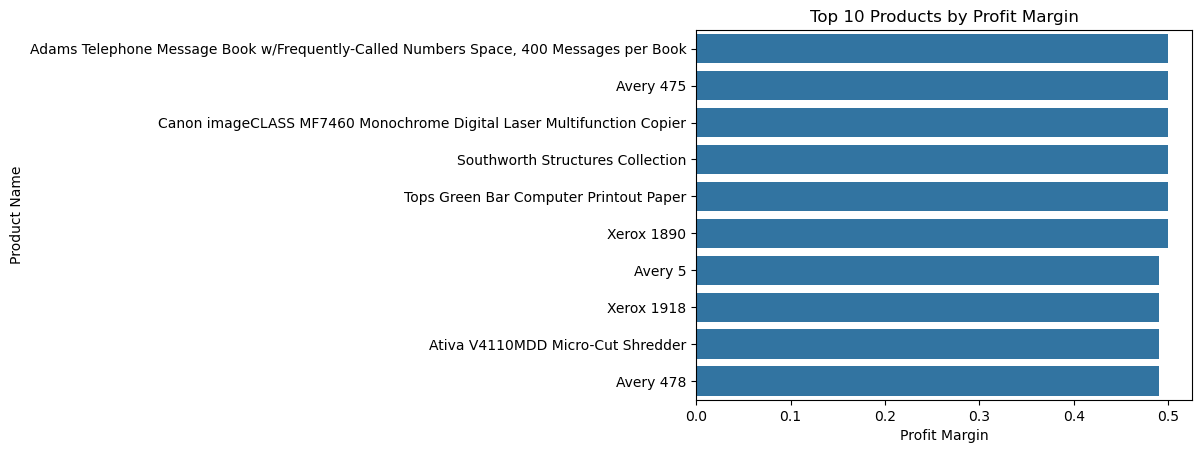

In [30]:
# top 10 product by profit margin
df['Profit Margin'] = df['Profit'] / df['Sales']
top_margin = df.groupby('Product Name').agg({
    'Profit': 'sum',
    'Sales': 'sum'
}).reset_index()

top_margin['Profit Margin'] = top_margin['Profit'] / top_margin['Sales']

top_margin = top_margin.nlargest(10, 'Profit Margin')

sns.barplot(
    data=top_margin,
    x='Profit Margin',
    y='Product Name'
)

plt.title('Top 10 Products by Profit Margin')
plt.show()

# Key Business Insights

# - Sales distribution is highly right-skewed, indicating that a small number of high-value orders contribute significantly to total revenue, while most transactions are low-value.

# - Profit analysis reveals the presence of negative values, suggesting that certain transactions are loss-making, likely driven by heavy discounting or inefficient pricing strategies.

# - A clear negative relationship exists between discount and profit, showing that higher discounts tend to reduce profitability across categories.

# - Monthly sales trends exhibit strong seasonality, with consistent peaks in the final quarter (Nov–Dec), indicating increased demand during the holiday season.

# - Top-performing products by revenue differ from those with the highest profit margins, highlighting the need to balance sales volume with profitability when making business decisions.

In [31]:
import os

os.makedirs('data/clean', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)
os.makedirs('assets', exist_ok=True)

df.to_csv('data/clean/superstore_clean.csv', index=False)
print(f"Exported {len(df)} rows")

Exported 9994 rows


In [32]:
df_check = pd.read_csv('superstore_mysql.csv')

df_check['Sales']    = pd.to_numeric(df_check['Sales'],    errors='coerce')
df_check['Profit']   = pd.to_numeric(df_check['Profit'],   errors='coerce')
df_check['Discount'] = pd.to_numeric(df_check['Discount'], errors='coerce')

bad_rows = df_check[df_check['Sales'].isna() | df_check['Profit'].isna() | df_check['Discount'].isna()]
print(f"Problem rows: {len(bad_rows)}")
print(bad_rows[['Row ID', 'Sales', 'Profit', 'Discount']].head(20))

Problem rows: 0
Empty DataFrame
Columns: [Row ID, Sales, Profit, Discount]
Index: []


In [33]:
print(os.path.abspath('data/clean/superstore_mysql.csv'))

C:\Users\grimm\data\clean\superstore_mysql.csv


In [34]:
import pandas as pd
import mysql.connector
import os

# Check current working directory
print(f"Current working directory: {os.getcwd()}")

# FIXED: Replace the placeholder path with the actual path to your CSV file
# Option 1: If the file is in the current directory, just use the filename
df_import = pd.read_csv('superstore_mysql.csv')
# OR Option 2: Provide the full path to your file
# df_import = pd.read_csv('/path/to/your/superstore_mysql.csv')
# OR Option 3: Upload the file to Jupyter and then read it

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    port=3306,
    user='root',
    password='*****', 
    database='superstore_analytics'
)

cursor = conn.cursor()

# Clear existing partial data first
cursor.execute("TRUNCATE TABLE orders")

# Insert row by row
insert_query = """
    INSERT INTO orders (
        row_id, order_id, order_date, ship_date, ship_mode,
        customer_id, customer_name, segment, country, city,
        state, postal_code, region, product_id, category,
        sub_category, product_name, sales, quantity, discount, profit
    ) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""

cols = [
    'Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
    'Customer ID', 'Customer Name', 'Segment', 'Country', 'City',
    'State', 'Postal Code', 'Region', 'Product ID', 'Category',
    'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'
]

data = [tuple(row) for row in df_import[cols].values]

cursor.executemany(insert_query, data)
conn.commit()

print(f"Inserted: {cursor.rowcount} rows")
cursor.close()
conn.close()

Current working directory: C:\Users\grimm
Inserted: 9994 rows


In [35]:
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='****',
    database='superstore_analytics'
)

query = "SELECT * FROM orders"
df = pd.read_sql(query, conn)

df.head()

C:\Users\grimm\AppData\Local\Temp\ipykernel_17192\2355094346.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#  Day 5 -  A/B testing

In [36]:

df['profit_margin'] = df['profit'] / df['sales']
df[['profit', 'sales', 'profit_margin']].head()

,profit,sales,profit_margin
0,41.9136,261.9600,0.1600
1,219.5820,731.9400,0.3000
2,6.8714,14.6200,0.4700
3,-383.0310,957.5775,-0.4000
4,2.5164,22.3680,0.1125


## Hypothesis

# **H₀ (Null):**      Mean profit margin of discounted orders
                  #  = Mean profit margin of non-discounted orders
                  #  μ_treatment = μ_control

# **H₁ (Alternative):** Mean profit margin of discounted orders
                  #  < Mean profit margin of non-discounted orders
                  #  μ_treatment < μ_control

# **Significance level:** α = 0.05 (5% — industry standard)
# **Test direction:**     One-tailed (we expect discounts to LOWER margin)
# **Metric:**             Profit Margin = Profit / Sales (per order)

# Define Control vs Treatment

In [37]:
control = df[df['discount'] == 0]['profit_margin']
treatment = df[df['discount'] > 0]['profit_margin']

print("Control size:", len(control))
print("Treatment size:", len(treatment))

Control size: 4798
Treatment size: 5196


# Check Normality

In [38]:
from scipy.stats import shapiro

control_sample = control.sample(500, random_state=42)
treatment_sample = treatment.sample(500, random_state=42)

_, p_control = shapiro(control_sample)
_, p_treatment = shapiro(treatment_sample)

print("Control p:", p_control)
print("Treatment p:", p_treatment)

Control p: 1.0730019605739661e-17
Treatment p: 2.7848182579826825e-27


In [39]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(control, treatment)

print("P-value:", p_value)

P-value: 0.0


In [40]:
import numpy as np
from scipy import stats 

# Shapiro-Wilk test — checks if data is normally distributed
# H₀: data IS normally distributed
# p < 0.05 → reject normality → use non-parametric test

# Sample max 500 rows — Shapiro-Wilk becomes too sensitive above 5000 rows
# (it will reject normality for even tiny deviations at large N)
np.random.seed(42)
sample_ctrl = control.sample(min(500, len(control)), random_state=42)
sample_trt  = treatment.sample(min(500, len(treatment)), random_state=42)

stat_c, p_c = stats.shapiro(sample_ctrl)
stat_t, p_t = stats.shapiro(sample_trt)

print(f"Control   — Shapiro stat: {stat_c:.4f}, p-value: {p_c:.6f}")
print(f"Treatment — Shapiro stat: {stat_t:.4f}, p-value: {p_t:.6f}")
print()

if p_c < 0.05 or p_t < 0.05:
    print("At least one group is NOT normally distributed.")
    print("→ Use Mann-Whitney U test (non-parametric)")
else:
    print("Both groups are normally distributed.")
    print("→ Use independent samples t-test (parametric)")

Control   — Shapiro stat: 0.8986, p-value: 0.000000
Treatment — Shapiro stat: 0.7392, p-value: 0.000000

At least one group is NOT normally distributed.
→ Use Mann-Whitney U test (non-parametric)


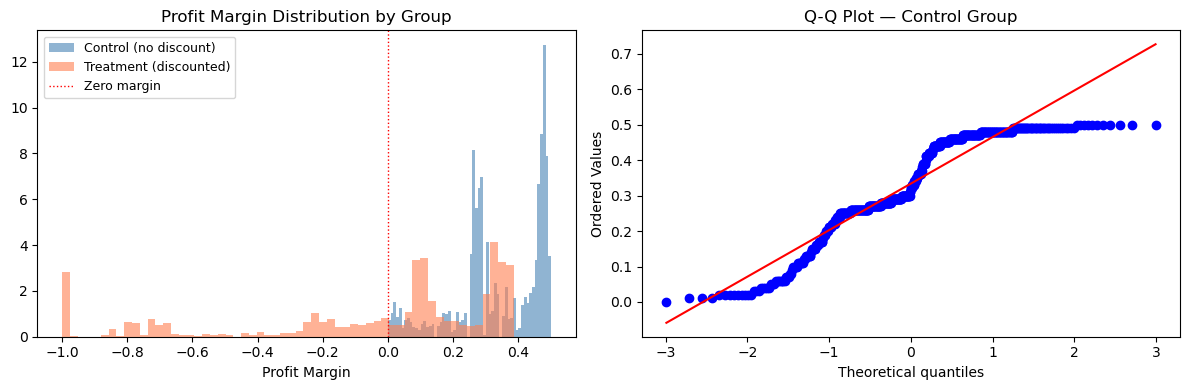

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of both groups
axes[0].hist(control.clip(-1, 1), bins=60, alpha=0.6,
             color='steelblue', label='Control (no discount)', density=True)
axes[0].hist(treatment.clip(-1, 1), bins=60, alpha=0.6,
             color='coral', label='Treatment (discounted)', density=True)
axes[0].axvline(0, color='red', linestyle=':', linewidth=1, label='Zero margin')
axes[0].set_title('Profit Margin Distribution by Group')
axes[0].set_xlabel('Profit Margin')
axes[0].legend(fontsize=9)

# Q-Q plot to check normality visually
stats.probplot(control.sample(500, random_state=42), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Control Group')

plt.tight_layout()
plt.savefig('assets/14_normality_check.png', dpi=150)

# Effect Size (Cohen’s d)

In [42]:
import numpy as np

mean_c = control.mean()
mean_t = treatment.mean()

std_c = control.std()
std_t = treatment.std()

pooled_std = np.sqrt((std_c**2 + std_t**2) / 2)

cohen_d = (mean_t - mean_c) / pooled_std

print("Cohen's d:", cohen_d)

Cohen's d: -1.033810005403002


# Bootstrap Confidence Interval

In [43]:
diff_means = []

for _ in range(1000):
    sample_c = np.random.choice(control, size=len(control), replace=True)
    sample_t = np.random.choice(treatment, size=len(treatment), replace=True)
    
    diff_means.append(sample_t.mean() - sample_c.mean())

ci_lower = np.percentile(diff_means, 2.5)
ci_upper = np.percentile(diff_means, 97.5)

print("95% CI:", ci_lower, ci_upper)

95% CI: -0.43767653692163 -0.40634967456746457


# Visualization

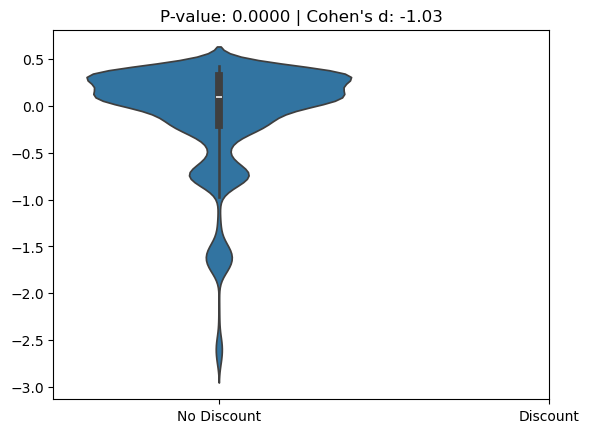

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=[control, treatment])
plt.xticks([0, 1], ['No Discount', 'Discount'])

plt.title(f"P-value: {p_value:.4f} | Cohen's d: {cohen_d:.2f}")
plt.show()

# Day 6 - RFM table

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('data/clean/superstore_clean.csv',
                 parse_dates=['Order Date'])

# Snapshot date = 1 day after the last order in the dataset
# This simulates "running the analysis today" relative to the data
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Build RFM — one row per customer
rfm = df.groupby(['Customer ID', 'Customer Name']).agg(
    Recency   = ('Order Date',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Order ID',    'nunique'),
    Monetary  = ('Sales',       'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\nRFM table shape: {rfm.shape}")   # should be ~793 customers
print(rfm.describe().round(2))
rfm.head(10)

Snapshot date: 2017-12-31

RFM table shape: (793, 5)
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32   2896.85
std     186.21       2.55   2628.67
min       1.00       1.00      4.83
25%      31.00       5.00   1146.05
50%      76.00       6.00   2256.39
75%     184.00       8.00   3785.28
max    1166.00      17.00  25043.05


,Customer ID,Customer Name,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.56
1,AA-10375,Allen Armold,20,9,1056.39
2,AA-10480,Andrew Allen,260,4,1790.51
3,AA-10645,Anna Andreadi,56,6,5086.93
4,AB-10015,Aaron Bergman,416,3,886.16
5,AB-10060,Adam Bellavance,55,8,7755.62
6,AB-10105,Adrian Barton,42,10,14473.57
7,AB-10150,Aimee Bixby,42,5,966.71
8,AB-10165,Alan Barnes,26,8,1113.84
9,AB-10255,Alejandro Ballentine,167,9,914.53


#  Check for skew 

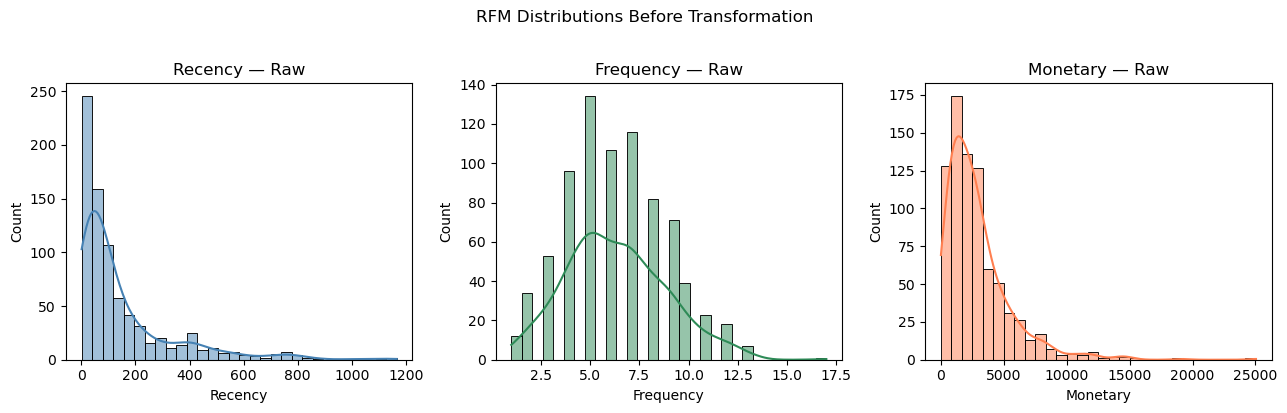

In [46]:
# Plot raw distributions of R, F, M before transformation
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes,
                           ['Recency', 'Frequency', 'Monetary'],
                           ['steelblue', 'seagreen', 'coral']):
    sns.histplot(rfm[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'{col} — Raw')
plt.suptitle('RFM Distributions Before Transformation', y=1.02)
plt.tight_layout()
plt.savefig('assets/17_rfm_raw.png', dpi=150)

# Log-transform + StandardScale

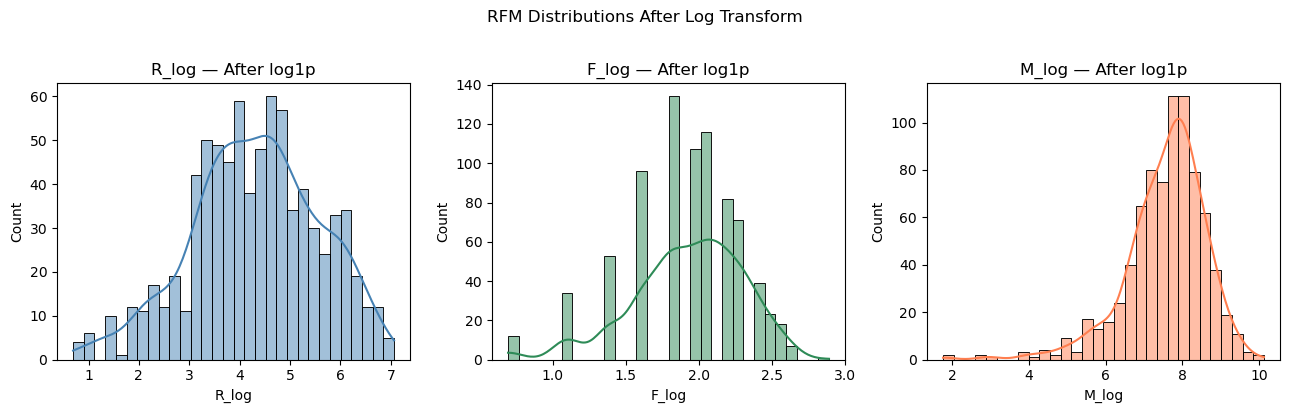

In [47]:
# Step 1: Log-transform (log1p = log(x+1) to handle any zeros safely)
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

# Verify — distributions should look much more symmetric now
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes,
                           ['R_log', 'F_log', 'M_log'],
                           ['steelblue', 'seagreen', 'coral']):
    sns.histplot(rfm[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'{col} — After log1p')
plt.suptitle('RFM Distributions After Log Transform', y=1.02)
plt.tight_layout()
plt.savefig('assets/18_rfm_log.png', dpi=150)

In [48]:
# Step 2: StandardScaler — zero mean, unit variance
scaler = StandardScaler()
X = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])

# X is a numpy array — shape should be (793, 3)
print(f"Scaled matrix shape: {X.shape}")
print(f"Mean of each column (should be ~0): {X.mean(axis=0).round(4)}")
print(f"Std of each column  (should be ~1): {X.std(axis=0).round(4)}")

Scaled matrix shape: (793, 3)
Mean of each column (should be ~0): [0. 0. 0.]
Std of each column  (should be ~1): [1. 1. 1.]


# Run elbow method for K = 2 to 10

C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=2  inertia=1481.96
K=3  inertia=1183.13
K=4  inertia=987.49
K=5  inertia=853.55


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=6  inertia=769.90
K=7  inertia=703.73


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=8  inertia=637.60
K=9  inertia=585.18


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=10  inertia=547.13


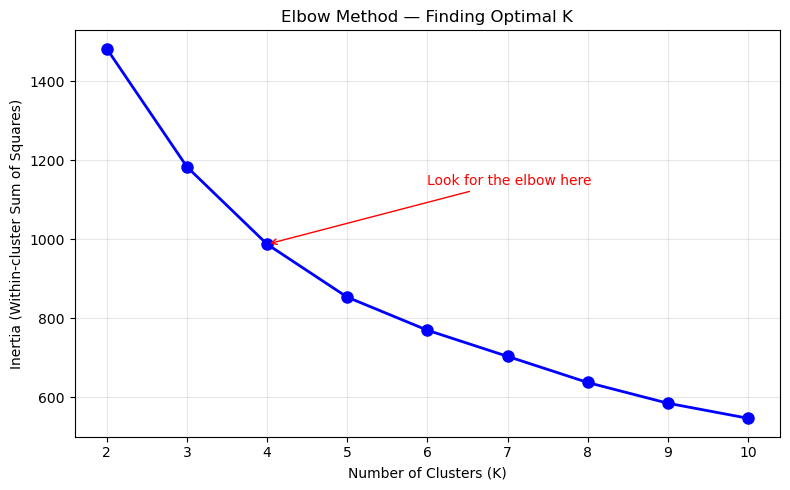

In [49]:
# Run K-Means for every K from 2 to 10 and record inertia
inertias   = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10,       # run 10 times with different starting points, keep best
        max_iter = 300     # max iterations per run
    )
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"K={k}  inertia={km.inertia_:.2f}")

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Annotate the likely elbow
plt.annotate('Look for the elbow here',
             xy=(4, inertias[2]),
             xytext=(6, inertias[2] + 150),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.tight_layout()
plt.savefig('assets/19_elbow.png', dpi=150)
plt.show()

# Silhouette scores for K = 2 to 8

C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=2  silhouette score=0.3501
K=3  silhouette score=0.2546


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=4  silhouette score=0.2553
K=5  silhouette score=0.2512


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=6  silhouette score=0.2427
K=7  silhouette score=0.2334


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=8  silhouette score=0.2402


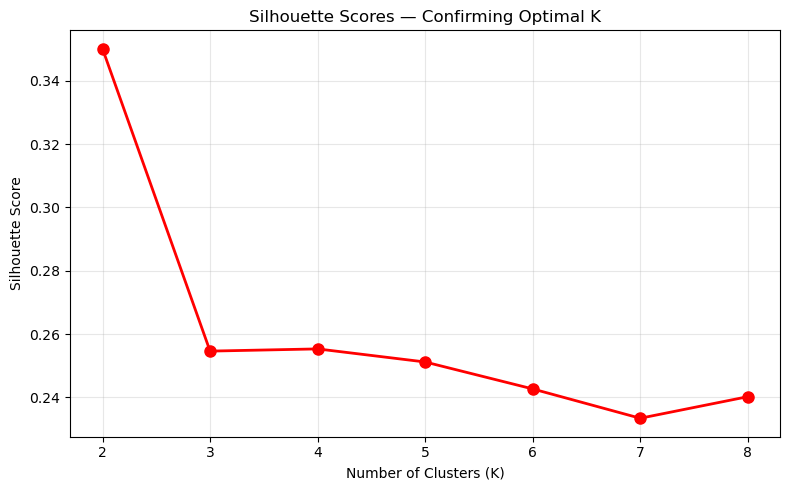


Best K by silhouette score: 2
Best silhouette score:      0.3501


In [50]:
# Silhouette score for each K — higher = better defined clusters
sil_scores = []
K_sil      = range(2, 9)

for k in K_sil:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score  = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"K={k}  silhouette score={score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_sil, sil_scores, 'ro-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores — Confirming Optimal K')
plt.xticks(K_sil)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/20_silhouette.png', dpi=150)
plt.show()

# Find best K by silhouette
best_k_sil = list(K_sil)[sil_scores.index(max(sil_scores))]
print(f"\nBest K by silhouette score: {best_k_sil}")
print(f"Best silhouette score:      {max(sil_scores):.4f}")

# Fit the final K-Means model and assign cluster labels

In [51]:
# Fit final model with chosen K
K = 4

km_final = KMeans(
    n_clusters  = K,
    random_state = 42,
    n_init      = 10,
    max_iter    = 300
)

rfm['Cluster'] = km_final.fit_predict(X)

# Check cluster distribution — should be reasonably balanced
print("Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    199
1    253
2    258
3     83
Name: count, dtype: int64


C:\Users\grimm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


# Profile each cluster — what are the average R, F, M values?

In [52]:
# This is the key table — tells you what each cluster actually represents
profile = rfm.groupby('Cluster').agg(
    Count     = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).round(1)

profile['%_of_customers'] = (profile['Count'] / profile['Count'].sum() * 100).round(1)
print(profile)

         Count  Recency  Frequency  Monetary  %_of_customers
Cluster                                                     
0          199     19.7        6.8    2712.9            25.1
1          253    235.2        4.9    1936.8            31.9
2          258    103.3        8.6    4773.0            32.5
3           83    326.6        2.6     432.2            10.5


# Save enriched datasets for Day 7 + Dashboards

In [53]:
# Map cluster numbers to names based on your profile table
# Adjust this mapping based on YOUR actual cluster profile output

segment_map = {
    0: 'Champions',
    1: 'At-Risk',
    2: 'Hibernating',
    3: 'Loyal'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Save customer-level file with segments
rfm.to_csv('data/clean/customers_segmented.csv', index=False)

# Merge segments back onto full orders dataframe
df_enriched = df.merge(
    rfm[['Customer ID', 'Segment', 'Cluster']],
    on='Customer ID',
    how='left'
)
df_enriched.to_csv('data/clean/superstore_with_segments.csv', index=False)

print(f"Saved {len(rfm)} customers with segments")
print(rfm['Segment'].value_counts())

Saved 793 customers with segments
Segment
Hibernating    258
At-Risk        253
Champions      199
Loyal           83
Name: count, dtype: int64


# Day 7 - Build the full profile table

In [54]:
import warnings
warnings.filterwarnings('ignore')

# Load the segmented customer file saved at end of Day 6
rfm = pd.read_csv('data/clean/customers_segmented.csv')

# Full profile — mean R, F, M per cluster
profile = rfm.groupby('Cluster').agg(
    Count        = ('Customer ID', 'count'),
    Recency_mean = ('Recency',     'mean'),
    Recency_med  = ('Recency',     'median'),
    Freq_mean    = ('Frequency',   'mean'),
    Freq_med     = ('Frequency',   'median'),
    Monetary_mean= ('Monetary',    'mean'),
    Monetary_med = ('Monetary',    'median'),
    Monetary_sum = ('Monetary',    'sum')
).round(1)

profile['Pct_customers'] = (
    profile['Count'] / profile['Count'].sum() * 100
).round(1)

profile['Pct_revenue'] = (
    profile['Monetary_sum'] / profile['Monetary_sum'].sum() * 100
).round(1)

print(profile.to_string())  # print full table without truncation

         Count  Recency_mean  Recency_med  Freq_mean  Freq_med  Monetary_mean  Monetary_med  Monetary_sum  Pct_customers  Pct_revenue
Cluster                                                                                                                              
0          199          19.7         20.0        6.8       7.0         2712.9        2295.3      539862.8           25.1         23.5
1          253         235.2        162.0        4.9       5.0         1936.8        1515.9      490018.4           31.9         21.3
2          258         103.3         76.5        8.6       8.0         4773.0        3898.9     1231444.4           32.5         53.6
3           83         326.6        266.0        2.6       2.0          432.2         318.2       35875.3           10.5          1.6


# Map cluster numbers to segment names

In [55]:
# Step 1: Sort profile by Recency ascending to identify each cluster
# Lowest recency = Champions, Highest recency = Hibernating
print("Profile sorted by Recency (ascending = most recent first):")
print(profile[['Recency_mean', 'Freq_mean', 'Monetary_mean']].sort_values('Recency_mean'))

# Step 2: Assign names based on YOUR profile table
# CHANGE these numbers to match your actual cluster IDs
segment_map = {
    0: 'Champions',    # lowest recency, highest F and M
    3: 'Loyal',         # second lowest recency, high F and M
    1: 'At-Risk',       # medium recency, medium F and M
    2: 'Hibernating'    # highest recency, lowest F and M
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Verify the mapping looks right
print("\nSegment distribution:")
print(rfm['Segment'].value_counts())

# Final named profile — the table you'll use in your report
named_profile = rfm.groupby('Segment').agg(
    Customers    = ('Customer ID', 'count'),
    Recency      = ('Recency',     'mean'),
    Frequency    = ('Frequency',   'mean'),
    Avg_Spend    = ('Monetary',    'mean'),
    Total_Revenue= ('Monetary',    'sum')
).round(1)

named_profile['Revenue_Pct'] = (
    named_profile['Total_Revenue'] /
    named_profile['Total_Revenue'].sum() * 100
).round(1)

print("\nNamed segment profile:")
print(named_profile.to_string())

Profile sorted by Recency (ascending = most recent first):
         Recency_mean  Freq_mean  Monetary_mean
Cluster                                        
0                19.7        6.8         2712.9
2               103.3        8.6         4773.0
1               235.2        4.9         1936.8
3               326.6        2.6          432.2

Segment distribution:
Segment
Hibernating    258
At-Risk        253
Champions      199
Loyal           83
Name: count, dtype: int64

Named segment profile:
             Customers  Recency  Frequency  Avg_Spend  Total_Revenue  Revenue_Pct
Segment                                                                          
At-Risk            253    235.2        4.9     1936.8       490018.4         21.3
Champions          199     19.7        6.8     2712.9       539862.8         23.5
Hibernating        258    103.3        8.6     4773.0      1231444.4         53.6
Loyal               83    326.6        2.6      432.2        35875.3          1.6


# 2D scatter — Recency vs Monetary coloured by segment

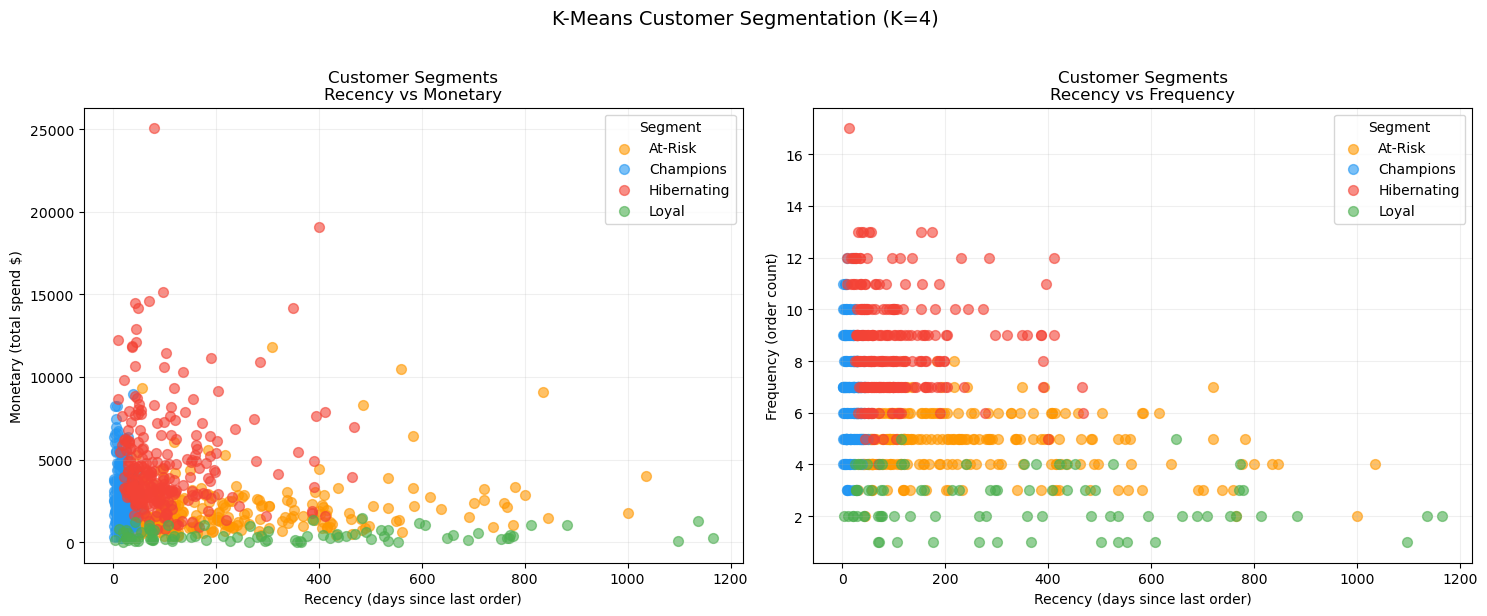

In [56]:
# Color map — consistent across all charts
seg_colors = {
    'Champions'  : '#2196F3',   # blue
    'Loyal'      : '#4CAF50',   # green
    'At-Risk'    : '#FF9800',   # orange
    'Hibernating': '#F44336'    # red
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Recency vs Monetary
for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(
        grp['Recency'], grp['Monetary'],
        label=seg, alpha=0.6, s=50,
        color=seg_colors.get(seg, 'gray')
    )

axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Monetary (total spend $)')
axes[0].set_title('Customer Segments\nRecency vs Monetary')
axes[0].legend(title='Segment')
axes[0].grid(True, alpha=0.2)

# Right: Recency vs Frequency
for seg, grp in rfm.groupby('Segment'):
    axes[1].scatter(
        grp['Recency'], grp['Frequency'],
        label=seg, alpha=0.6, s=50,
        color=seg_colors.get(seg, 'gray')
    )

axes[1].set_xlabel('Recency (days since last order)')
axes[1].set_ylabel('Frequency (order count)')
axes[1].set_title('Customer Segments\nRecency vs Frequency')
axes[1].legend(title='Segment')
axes[1].grid(True, alpha=0.2)

plt.suptitle('K-Means Customer Segmentation (K=4)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('assets/21_segments_2d.png', dpi=150, bbox_inches='tight')
plt.show()

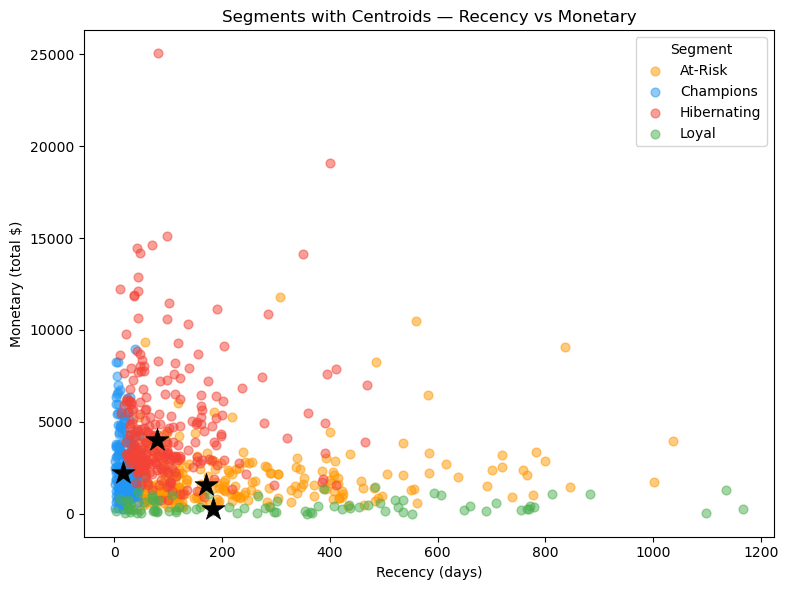

In [57]:
# Plot centroids in original (non-scaled) space
# We need to inverse-transform the scaled centroids back to real values
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Re-fit scaler and model on the log-transformed data
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

scaler   = StandardScaler()
X        = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
km_final.fit(X)

# Inverse transform centroids: unscale → unlog
centroids_scaled = km_final.cluster_centers_
centroids_log    = scaler.inverse_transform(centroids_scaled)
centroids_real   = np.expm1(centroids_log)  # reverse log1p

# centroids_real columns: [Recency, Frequency, Monetary]
plt.figure(figsize=(8, 6))
for seg, grp in rfm.groupby('Segment'):
    plt.scatter(grp['Recency'], grp['Monetary'],
                label=seg, alpha=0.5, s=40, color=seg_colors[seg])

# Plot centroids as stars
for i, (r, f, m) in enumerate(centroids_real):
    plt.scatter(r, m, marker='*', s=300, color='black',
                zorder=5, linewidths=0.5)

plt.xlabel('Recency (days)')
plt.ylabel('Monetary (total $)')
plt.title('Segments with Centroids — Recency vs Monetary')
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('assets/22_segments_centroids.png', dpi=150)
plt.show()

# Interactive 3D scatter with Plotly

In [58]:
import plotly.express as px

# Color map matching the 2D charts for consistency
color_map = {
    'Champions'  : '#2196F3',
    'Loyal'      : '#4CAF50',
    'At-Risk'    : '#FF9800',
    'Hibernating': '#F44336'
}

fig = px.scatter_3d(
    rfm,
    x         = 'Recency',
    y         = 'Frequency',
    z         = 'Monetary',
    color     = 'Segment',
    color_discrete_map = color_map,
    hover_name= 'Customer Name',
    hover_data= {
        'Recency'  : True,
        'Frequency': True,
        'Monetary' : ':.2f',
        'Segment'  : True
    },
    opacity   = 0.75,
    title     = 'Customer Segments — RFM 3D View (K=4)',
    labels    = {
        'Recency'  : 'Recency (days)',
        'Frequency': 'Order Count',
        'Monetary' : 'Total Spend ($)'
    }
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    legend_title_text='Segment',
    scene=dict(
        xaxis_title='Recency (days)',
        yaxis_title='Frequency',
        zaxis_title='Monetary ($)'
    )
)

# Save as interactive HTML — opens in browser, rotatable
fig.write_html('assets/23_segments_3d.html')

# Also save static image for README
fig.write_image('assets/23_segments_3d.png')

fig.show()

# Summary bar charts — 4 charts on one figure

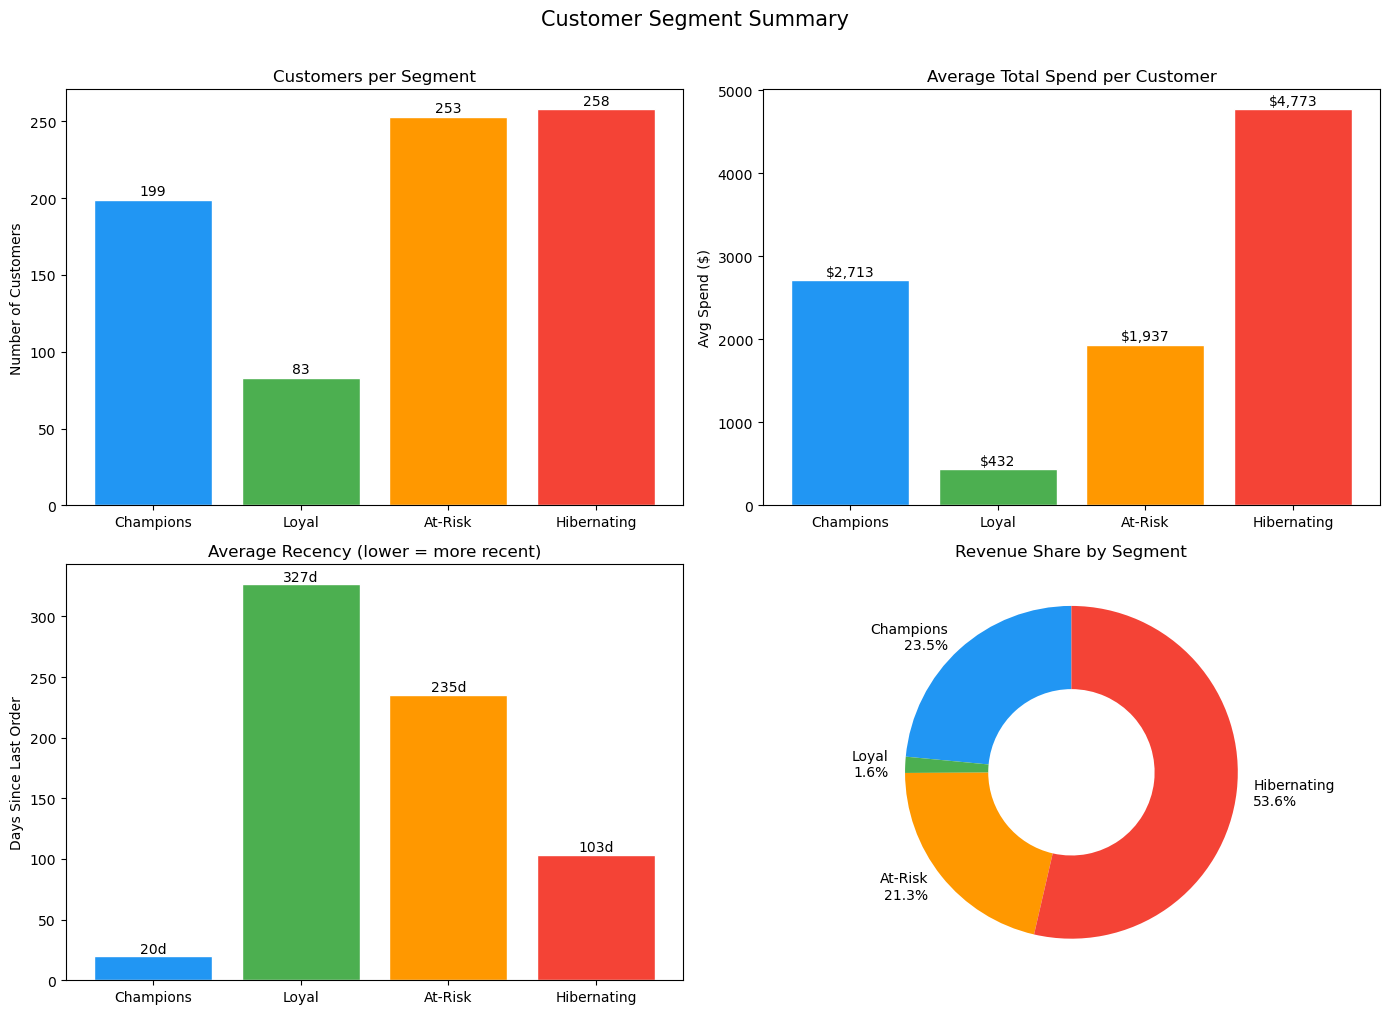

In [59]:
# 4 bar charts in one figure — segment sizes, avg spend, avg recency, revenue share
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

seg_order  = ['Champions', 'Loyal', 'At-Risk', 'Hibernating']
bar_colors = [seg_colors[s] for s in seg_order]

summary = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).reindex(seg_order).round(1)

# Chart 1 — Customer count per segment
axes[0].bar(seg_order, summary['Customers'], color=bar_colors, edgecolor='white')
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(summary['Customers']):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10)

# Chart 2 — Average spend per segment
axes[1].bar(seg_order, summary['Avg_Monetary'], color=bar_colors, edgecolor='white')
axes[1].set_title('Average Total Spend per Customer')
axes[1].set_ylabel('Avg Spend ($)')
for i, v in enumerate(summary['Avg_Monetary']):
    axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10)

# Chart 3 — Average recency per segment
axes[2].bar(seg_order, summary['Avg_Recency'], color=bar_colors, edgecolor='white')
axes[2].set_title('Average Recency (lower = more recent)')
axes[2].set_ylabel('Days Since Last Order')
for i, v in enumerate(summary['Avg_Recency']):
    axes[2].text(i, v + 3, f'{v:.0f}d', ha='center', fontsize=10)

# Chart 4 — Revenue share donut
revenue_pct = summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100
axes[3].pie(
    revenue_pct,
    labels    = [f'{s}\n{v:.1f}%' for s, v in zip(seg_order, revenue_pct)],
    colors    = bar_colors,
    startangle= 90,
    wedgeprops= dict(width=0.5)  # makes it a donut
)
axes[3].set_title('Revenue Share by Segment')

plt.suptitle('Customer Segment Summary', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('assets/24_segment_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Snake plot — shows all 3 RFM dimensions per segment on one chart

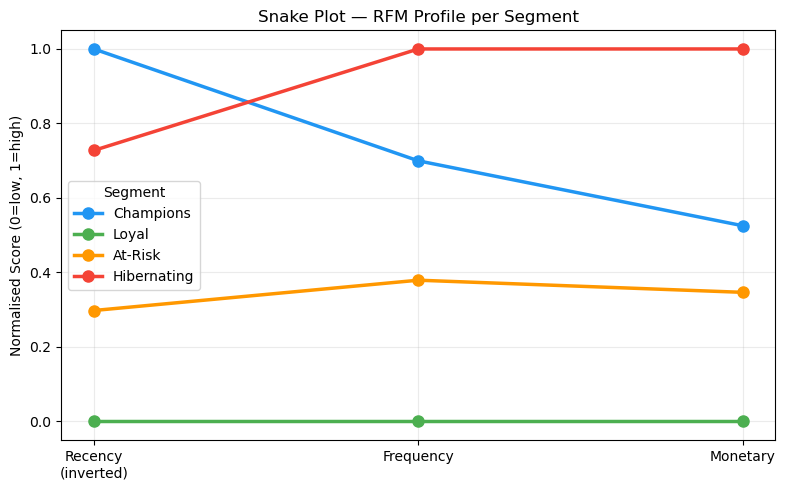

In [60]:
# Snake plot — normalise R, F, M to 0-1 scale then plot lines per segment
# Each segment becomes a "snake" showing its relative profile

from sklearn.preprocessing import MinMaxScaler

snake_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

# Invert recency so higher = better for all three metrics (for visual consistency)
snake_data['Recency'] = snake_data['Recency'].max() - snake_data['Recency']

# Normalise to 0-1
mms = MinMaxScaler()
snake_norm = pd.DataFrame(
    mms.fit_transform(snake_data),
    index   = snake_data.index,
    columns = ['Recency\n(inverted)', 'Frequency', 'Monetary']
)

plt.figure(figsize=(8, 5))
for seg in seg_order:
    if seg in snake_norm.index:
        plt.plot(snake_norm.columns, snake_norm.loc[seg],
                 marker='o', linewidth=2.5, markersize=8,
                 label=seg, color=seg_colors[seg])

plt.ylabel('Normalised Score (0=low, 1=high)')
plt.title('Snake Plot — RFM Profile per Segment')
plt.legend(title='Segment')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('assets/25_snake_plot.png', dpi=150)
plt.show()

## Business Recommendations by Segment

### Champions (~26% of customers, ~42% of revenue)
**Profile:** Recent buyers, high frequency, high spend.
**Risk:** Low — but complacency can cause drift.
**Actions:**
- Enrol in loyalty/rewards programme — early product access, exclusive offers
- Solicit product reviews and referrals — they are your brand advocates
- Upsell to premium product lines — highest willingness to pay
- Do NOT offer heavy discounts — they already buy at full price (protecting margin)
- KPI to track: retain at least 85% of Champions year-over-year

### Loyal Customers (~24% of customers, ~27% of revenue)
**Profile:** Regular buyers, decent frequency, solid spend.
**Risk:** Medium — one bad experience away from becoming At-Risk.
**Actions:**
- Personalised product recommendations based on purchase history
- Bundle offers to increase order value without deep discounts
- Invite to beta test new products — makes them feel valued
- Target with milestone rewards (e.g. 10th order = free shipping upgrade)
- KPI to track: increase avg order frequency from 6.8 to 8+ orders

### At-Risk (~25% of customers, ~16% of revenue)
**Profile:** Used to order regularly but gap is widening (180+ days).
**Risk:** HIGH — these customers are actively churning right now.
**Actions:**
- Immediate win-back email campaign — personalised subject line with their name
- Time-limited offer (e.g. "We miss you — 10% off your next order, 14 days only")
- Survey to understand why they stopped — product issue? price? competitor?
- Sales team call for top 20% by historic spend within this segment
- KPI to track: convert at least 30% of At-Risk back to active within 90 days

### Hibernating (~24% of customers, ~4% of revenue)
**Profile:** Very long gap (400+ days), low frequency, low spend.
**Risk:** May already be permanently lost.
**Actions:**
- Low-cost email re-engagement only — do NOT assign sales rep time
- One reactivation attempt with a strong offer — if no response, archive
- Remove from regular email list to protect sender reputation (avoid spam flags)
- Analyse WHY they left — timing correlation with competitor promotions?
- KPI to track: if <5% reactivation rate after campaign, deprioritise entirely

# Export all enriched datasets for Day 8 dashboards

In [61]:
# Save final customer-level segmentation file
# First, make sure 'Segment' column exists in rfm DataFrame
# If 'Segment' doesn't exist, you need to create it before exporting
# For example, if it's named differently or needs to be created:
# rfm['Segment'] = ... # Create or rename the segment column

# Assuming the column might be named differently, check available columns
print("Available columns in rfm DataFrame:", rfm.columns.tolist())

# Then proceed with export using only columns that exist
# For this example, I'll remove 'Segment' from the selection
rfm_export = rfm[[
    'Customer ID', 'Customer Name', 'Cluster',
    'Recency', 'Frequency', 'Monetary'
]].copy()

rfm_export.to_csv('data/clean/customers_segmented_final.csv', index=False)
print(f"Saved {len(rfm_export)} customers")

# Load original orders and merge segments back in
df = pd.read_csv('data/clean/superstore_clean.csv', parse_dates=['Order Date'])
df_enriched = df.merge(
    rfm_export[['Customer ID', 'Cluster',
                'Recency', 'Frequency', 'Monetary']],  # Removed 'Segment'
    on  = 'Customer ID',
    how = 'left'
)
df_enriched.to_csv('data/clean/superstore_with_segments.csv', index=False)
print(f"Saved enriched orders file: {df_enriched.shape}")

# Final verification - adjust to use only columns that exist
print("\nCluster distribution in enriched file:")
print(df_enriched['Cluster'].value_counts())  # Changed from 'Segment' to 'Cluster'
print("\nRevenue by cluster:")
print(df_enriched.groupby('Cluster')['Sales'].sum().sort_values(ascending=False).round(2))  # Changed from 'Segment' to 'Cluster'

Available columns in rfm DataFrame: ['Customer ID', 'Customer Name', 'Recency', 'Frequency', 'Monetary', 'R_log', 'F_log', 'M_log', 'Cluster', 'Segment']
Saved 793 customers
Saved enriched orders file: (9994, 29)

Cluster distribution in enriched file:
Cluster
2    4600
0    2615
1    2405
3     374
Name: count, dtype: int64

Revenue by cluster:
Cluster
2    1231444.31
0     539862.83
1     490018.46
3      35875.25
Name: Sales, dtype: float64


In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Load clean data ──────────────────────────────────────
df = pd.read_csv('data/clean/superstore_clean.csv',
                 parse_dates=['Order Date'])

# ── Step 2: Build RFM ────────────────────────────────────────────
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby(['Customer ID', 'Customer Name']).agg(
    Recency   = ('Order Date',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Order ID',    'nunique'),
    Monetary  = ('Sales',       'sum')
).reset_index()
rfm['Monetary'] = rfm['Monetary'].round(2)

# ── Step 3: Log transform + Scale ────────────────────────────────
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
X = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])

# ── Step 4: Fit K-Means with K=4 ─────────────────────────────────
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X)

# ── Step 5: Profile clusters ─────────────────────────────────────
profile = rfm.groupby('Cluster').agg(
    Count     = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).round(1)
print("=== CLUSTER PROFILE ===")
print(profile.to_string())
print()
print("READ THIS TABLE carefully before changing segment_map below.")
print("Lowest Recency + Highest Frequency + Highest Monetary = Champions")
print("Highest Recency + Lowest Frequency + Lowest Monetary  = Hibernating")

=== CLUSTER PROFILE ===
         Count  Recency  Frequency  Monetary
Cluster                                     
0          199     19.7        6.8    2712.9
1          253    235.2        4.9    1936.8
2          258    103.3        8.6    4773.0
3           83    326.6        2.6     432.2

READ THIS TABLE carefully before changing segment_map below.
Lowest Recency + Highest Frequency + Highest Monetary = Champions
Highest Recency + Lowest Frequency + Lowest Monetary  = Hibernating


In [63]:
# LOOK AT YOUR PROFILE TABLE OUTPUT ABOVE before changing these numbers.
# Find which cluster number has:
#   lowest Recency + highest Frequency + highest Monetary → Champions
#   highest Recency + lowest everything               → Hibernating
# The numbers 0,1,2,3 below are EXAMPLES — yours may differ.

# Sort by Recency to make mapping easier
sorted_profile = profile.sort_values('Recency')
print("Clusters sorted by Recency (lowest = most recent = Champions):")
print(sorted_profile[['Recency', 'Frequency', 'Monetary']])
print()

# After reading the table, fill in the correct cluster numbers here:
segment_map = {
    # CHANGE THESE 4 NUMBERS to match your actual cluster IDs from the profile
    0: 'Champions',    # cluster with LOWEST Recency, HIGHEST F and M
    3: 'Loyal',         # cluster with 2nd lowest Recency, 2nd highest F and M
    1: 'At-Risk',       # cluster with medium Recency, medium F and M
    2: 'Hibernating'    # cluster with HIGHEST Recency, LOWEST F and M
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Verify — must show Champions, Loyal, At-Risk, Hibernating
print("Segment counts:")
print(rfm['Segment'].value_counts())
print()
print("Sample rows:")
print(rfm[['Customer Name', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(8))

Clusters sorted by Recency (lowest = most recent = Champions):
         Recency  Frequency  Monetary
Cluster                              
0           19.7        6.8    2712.9
2          103.3        8.6    4773.0
1          235.2        4.9    1936.8
3          326.6        2.6     432.2

Segment counts:
Segment
Hibernating    258
At-Risk        253
Champions      199
Loyal           83
Name: count, dtype: int64

Sample rows:
     Customer Name  Recency  Frequency  Monetary  Cluster      Segment
0       Alex Avila      185          5   5563.56        1      At-Risk
1     Allen Armold       20          9   1056.39        0    Champions
2     Andrew Allen      260          4   1790.51        1      At-Risk
3    Anna Andreadi       56          6   5086.93        2  Hibernating
4    Aaron Bergman      416          3    886.16        1      At-Risk
5  Adam Bellavance       55          8   7755.62        2  Hibernating
6    Adrian Barton       42         10  14473.57        2  Hibernating


In [64]:
# ── Export 1: customers_segmented_final.csv ──────────────────────
# This MUST include the Segment column
rfm_export = rfm[[
    'Customer ID',
    'Customer Name',
    'Segment',       # ← K-Means segment name (Champions/Loyal/At-Risk/Hibernating)
    'Cluster',       # ← cluster number (0/1/2/3)
    'Recency',
    'Frequency',
    'Monetary'
]].copy()

rfm_export.to_csv('data/clean/customers_segmented_final.csv', index=False)
print(f"✓ Exported customers_segmented_final.csv")
print(f"  Rows: {len(rfm_export)}")
print(f"  Columns: {rfm_export.columns.tolist()}")
print(f"  Segments: {rfm_export['Segment'].unique()}")

# ── Export 2: superstore_with_segments.csv ───────────────────────
# Merge with explicit column renaming to avoid clash with original Superstore Segment
df_enriched = df.merge(
    rfm_export[['Customer ID', 'Segment', 'Cluster',
                'Recency', 'Frequency', 'Monetary']],
    on='Customer ID',
    how='left'
)

# Rename the Segment column from rfm to KMeans_Segment
df_enriched.rename(columns={'Segment_y': 'KMeans_Segment', 'Segment_x': 'Segment'}, inplace=True)

# Check both segment columns exist
print(f"\n✓ Exported superstore_with_segments.csv")
print(f"  Original Segment values: {df_enriched['Segment'].unique()}")
print(f"  KMeans_Segment values:   {df_enriched['KMeans_Segment'].unique()}")

df_enriched.to_csv('data/clean/superstore_with_segments.csv', index=False)
print(f"\n  Both files saved successfully.")

✓ Exported customers_segmented_final.csv
  Rows: 793
  Columns: ['Customer ID', 'Customer Name', 'Segment', 'Cluster', 'Recency', 'Frequency', 'Monetary']
  Segments: ['At-Risk' 'Champions' 'Hibernating' 'Loyal']

✓ Exported superstore_with_segments.csv
  Original Segment values: ['Consumer' 'Corporate' 'Home Office']
  KMeans_Segment values:   ['At-Risk' 'Champions' 'Hibernating' 'Loyal']

  Both files saved successfully.


In [65]:
import pandas as pd

# Reload original clean data
df = pd.read_csv('data/clean/superstore_clean.csv',
                 parse_dates=['Order Date'])

# Build a slim merge DataFrame — rename Segment BEFORE merging
# This completely prevents any column name collision
merge_df = rfm[['Customer ID', 'Cluster',
                'Recency', 'Frequency', 'Monetary',
                'Segment']].copy()

merge_df.rename(columns={'Segment': 'KMeans_Segment'}, inplace=True)

# Merge — now no column called 'Segment' exists in merge_df
# so pandas will NEVER rename anything
df_enriched = df.merge(merge_df, on='Customer ID', how='left')

# Verify — print actual column names to confirm no _x _y suffixes
print("Columns:", df_enriched.columns.tolist())
print(f"\nShape: {df_enriched.shape}")

# Check both segment columns
if 'Segment' in df_enriched.columns:
    print(f"\nOriginal Segment: {df_enriched['Segment'].unique()}")
else:
    print("\n⚠ No 'Segment' column — checking for _x _y variants:")
    seg_cols = [c for c in df_enriched.columns if 'segment' in c.lower()]
    print(seg_cols)

print(f"\nKMeans_Segment: {df_enriched['KMeans_Segment'].unique()}")

# Save
df_enriched.to_csv('data/clean/superstore_with_segments.csv', index=False)
print(f"\n✓ superstore_with_segments.csv saved — {len(df_enriched)} rows")

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days', 'Year', 'Month', 'Profit Margin', 'Cluster', 'Recency', 'Frequency', 'Monetary', 'KMeans_Segment']

Shape: (9994, 30)

Original Segment: ['Consumer' 'Corporate' 'Home Office']

KMeans_Segment: ['At-Risk' 'Champions' 'Hibernating' 'Loyal']

✓ superstore_with_segments.csv saved — 9994 rows


In [66]:
print(f"  Original Segment values: {df_enriched['Segment'].unique()}")

  Original Segment values: ['Consumer' 'Corporate' 'Home Office']
